# Incidence matrix
This notebook demonstrates how to create **categorical heatmaps** using the `draw_incidencematrix` function.

The function is designed to visualise incidence matrices — binary or categorical tables that represent the presence, 
absence, or category membership of elements across two dimensions (e.g. samples × features, individuals × conditions). 
Instead of traditional colour gradients, each matrix cell is represented by a point (dot), whose:
- **colour** reflects a value range,
- **size** and **transparency** encode importance or emphasis,
- **grid lines** define the structure of the matrix.

This type of visualisation is particularly useful for:
- displaying *sparse categorical* data (e.g. membership matrices, clustering overlap),
- highlighting combinations of binary or ordinal traits,
- providing clear, publication-ready figures without relying on colour scales.

The function is fully customisable and integrates with `matplotlib`, supporting adjustments to axis labels, tick sizes, margins, and more.
The examples below walk through usage of `draw_incidencematrix`, including custom dot mappings, grid styling, and axis formatting.

In [1]:
# %%%%%%%% imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plot_misc import incidencematrix as imat_plt
import plot_misc.example_data.examples as examples

In [2]:
# load data
data = examples.load_incidence_matrix_data()
# remove the counts (sum) column
del data['Counts']
data.head()

,APCS,C4BPB,IL1RN,KRTCAP3,RNASEH2B,TRIB1,ZNF644
AAA,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ALP,0.0,0.0,1.0,0.0,0.0,1.0,1.0
ALT,0.0,0.0,0.0,0.0,0.0,1.0,0.0
AST,0.0,0.0,1.0,0.0,0.0,1.0,0.0
Adiponectin,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [3]:
# constants
DOT_COLOUR = [('#C4C4C4', 0), ('#B12137', np.inf)]
DOT_SIZE = [30, 90]
TICK_LAB_SIZE = (10, 10)
MARGINS = (0.060, 0.015)

## Depicting an binary matrix


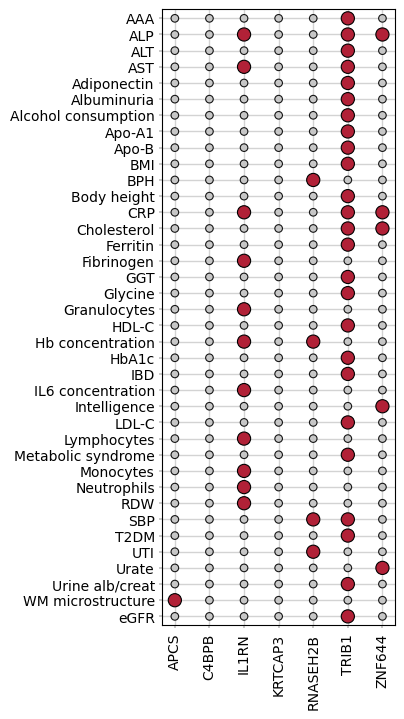

In [4]:
f, ax = imat_plt.draw_incidencematrix(data.iloc[::-1].T, fsize=(3,8),
                                dot_colour=DOT_COLOUR,
                                dot_size=DOT_SIZE,
                                lw = [1,1],
                                tick_lab_size=TICK_LAB_SIZE,
                                margins=MARGINS,
                                kwargs_scatter_dict={'edgecolor': 'black',
                                                     'linewidths':0.8,
                                                     }
                                )

## Drawing a grid outline

By placing the grid around the dots and remove the grey dots we obtain a very different variable more like an indicator table. 

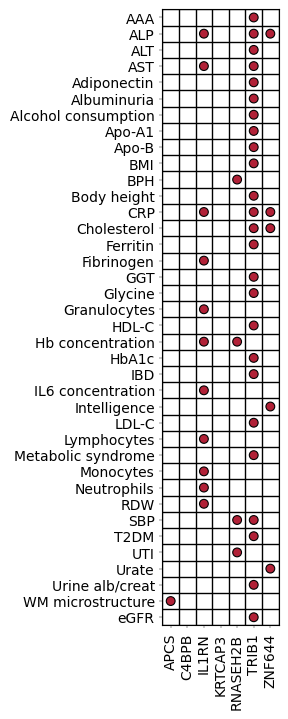

In [5]:
f, ax = imat_plt.draw_incidencematrix(data.iloc[::-1].T, fsize=(1.5,8),
                                dot_colour=DOT_COLOUR,
                                dot_size=[0, 40],
                                tick_lab_size=TICK_LAB_SIZE,
                                lw = [1,1],
                                line_colour=['black', 'black'],
                                margins = [0, 0],
                                grid_position='outline',
                                kwargs_scatter_dict={'edgecolor': 'black',
                                                     'linewidths':0.8,
                                                     },
                                kwargs_vline_dict={'linestyle': '-',},
                                kwargs_hline_dict={'linestyle': '-',},
                                )

## Plotting matrices with more than two values


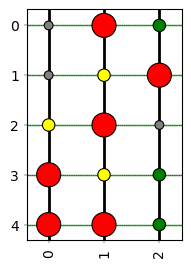

In [6]:
np.random.seed(2)
data2 = pd.DataFrame(np.random.randint(4, size=(5, 3)))
DOT_COLOUR = [('grey', 0), ('green', 1), ('yellow', 2), ('red', 3)]
DOT_SIZE = [40, 80, 80, 300,  ]
DOT_T = [1]
MARGINS = (0.2, 0.08)
f, ax = imat_plt.draw_incidencematrix(data2.iloc[::-1].T, fsize=(2,3),
                                dot_colour=DOT_COLOUR,
                                dot_size=DOT_SIZE,
                                dot_transparency=DOT_T,
                                tick_lab_size=TICK_LAB_SIZE,
                                lw=[2, 1],
                                line_colour=['black', 'green'],
                                margins=MARGINS,
                                kwargs_scatter_dict={'edgecolor': 'black',
                                                     'linewidths':0.8,
                                                     }
                                )
ax.grid(which='major', axis='y', linestyle=':', linewidth=0.5)

## Creating a "bubble heatmap"

The incidence matrix can also be used to create a bubble heatmap. For the first try we will create a chart with a chart with colours, sizes, and alphas baed on the same array applying distinct cut-offs.

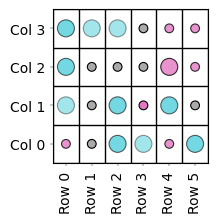

In [7]:
# Dummy data
np.random.seed(42)
data = pd.DataFrame(np.random.rand(6, 4),
                    index=[f"Row {i}" for i in range(6)],
                    columns=[f"Col {j}" for j in range(4)])
# Define cut-offs and mappings
DOT_COLOUR = [
    ("#AAAAAA", 0.2),   # grey for (−inf, 0.2]
    ("#E377C2", 0.5),   # pink for (0.2, 0.5]
    ("#17BECF", 1.0),   # blue for (0.5, 1.0]
]
# Size thresholds: 2 categories
DOT_SIZE = [
    (40, 0.4),          # small dots for (−inf, 0.4]
    (150, 1.0),          # large dots for (0.4, 1.0]
]
# Transparency thresholds: 4 categories
DOT_TRANSPARENCY = [
    (1.0, 0.25),        # very faint for (−inf, 0.25]
    (0.8, 0.5),         # light for (0.25, 0.5]
    (0.6, 0.75),        # medium for (0.5, 0.75]
    (0.4, 1.0),         # solid for (0.75, 1.0]
]
TICK_LAB_SIZE = (10, 10)
MARGINS = (0.05, 0.05)
fig, ax = imat_plt.draw_incidencematrix(
    data=data,
    fsize=(2, 2),
    lw = [1,1],
    line_colour=['black', 'black'],
    dot_colour=DOT_COLOUR,
    dot_size=DOT_SIZE,
    dot_transparency=DOT_TRANSPARENCY,
    tick_lab_size=TICK_LAB_SIZE,
    margins=[0,0],
    grid_position='outline',
    kwargs_scatter_dict={'edgecolor': 'black', 'linewidths': 0.8},
)

### Bubble chart with mappings on effect size and p-value

Next we create a chart which maps the colour based on the effect size and the size based on a second pd.DataFrame with the matching p-values.

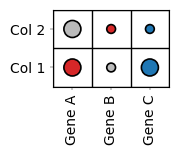

In [8]:
# effect size
data = pd.DataFrame({
    "Col 1": [-1.2, 0.1, 1.5],
    "Col 2": [-0.15, -0.8, 2.0],
}, index=["Gene A", "Gene B", "Gene C"])
# p-values
size_data = pd.DataFrame({
    "Col 1": [0.05, 0.3, 0.04],
    "Col 2": [0.01, 0.15, 0.5],
}, index=data.index)

# mapping rules
DOT_COLOUR = [
    ("#d62728", -0.2),    # red: strong negative effects (≤ −0.2)
    ("#bbbbbb", 0.2),     # grey: neutral (−0.2 to 0.2]
    ("#1f77b4", np.inf),  # blue: strong positive effects (> 0.2)
]
DOT_SIZE = [
    (150, 0.05),   # large if p < 0.05
    (40, 1.0),     # small otherwise
]
# plotting
TICK_LAB_SIZE = (10, 10)
MARGINS = (0.05, 0.05)
fig, ax = imat_plt.draw_incidencematrix(
    data=data,
    size_data=size_data,
    fsize=(3/2, 2/2),
    lw = [1,1],
    line_colour=['black', 'black'],
    dot_colour=DOT_COLOUR,
    dot_size=DOT_SIZE,
    dot_transparency=[1.0],
    tick_lab_size=TICK_LAB_SIZE,
    margins=[0,0],
    grid_position='outline',
    kwargs_scatter_dict={'edgecolor': 'black', 'linewidths': 1.2},
)

In [9]:
help(imat_plt)

Help on module plot_misc.incidencematrix in plot_misc:

NAME
    plot_misc.incidencematrix - Incidence matrix plotting for categorical heatmaps and set visualisation.

DESCRIPTION
    This module provides a plotting function for drawing incidence matrices,
    where each cell in a 2D grid is populated with a marker (dot) based on the
    underlying matrix value. This is useful for visualising categorical
    presence/absence patterns, binary annotations, or simplified heatmaps
    without continuous shading.
    
    The visual output is a grid of vertical and horizontal lines forming an
    n-by-m lattice, with overlaid points coloured and sized according to
    user-defined thresholds and formatting options.
    
    Functions
    ---------
    draw_incidencematrix(data, fsize=(6,6), ...)
        Draws a categorical incidence matrix, customising grid lines, dot styles,
        and axis labels using a DataFrame as input.
    
    Notes
    -----
    Each dot is rendered using `matplot